Dataset Shape: (2640, 12)
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)       

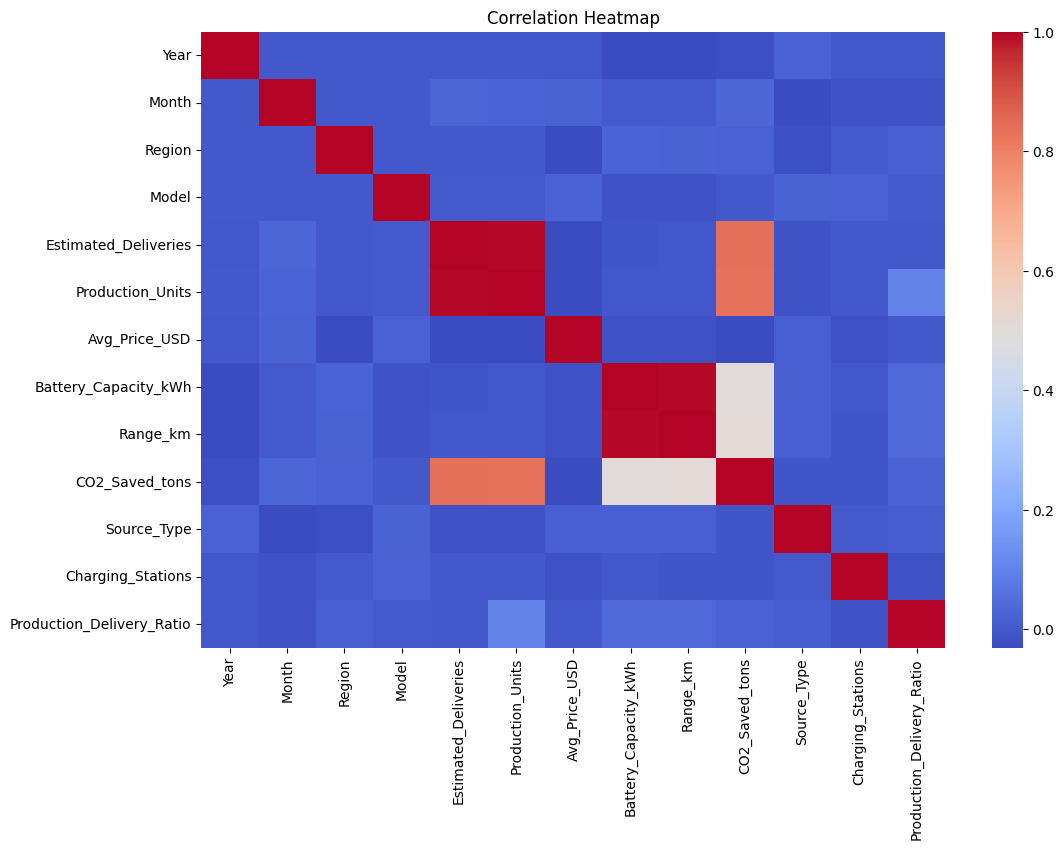

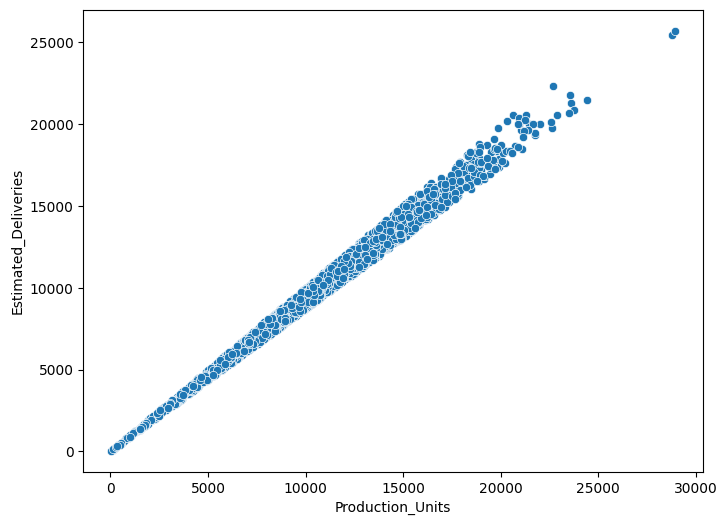


LINEAR REGRESSION
MAE: 107.72974260305637
RMSE: 153.64606127684166
R2 Score: 0.9984162984148737

RANDOM FOREST
MAE: 65.40916666666666
RMSE: 105.78350385696992
R2 Score: 0.9992493000545947

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

TUNED RANDOM FOREST
MAE: 67.53723199020406
RMSE: 112.12677494757173
R2 Score: 0.9991565697947556

Top Features
                      Feature  Importance
4            Production_Units    0.990636
11  Production_Delivery_Ratio    0.008643
8              CO2_Saved_tons    0.000194
5               Avg_Price_USD    0.000107
10          Charging_Stations    0.000076
1                       Month    0.000071
7                    Range_km    0.000065
0                        Year    0.000061
2                      Region    0.000049
9                 Source_Type    0.000045


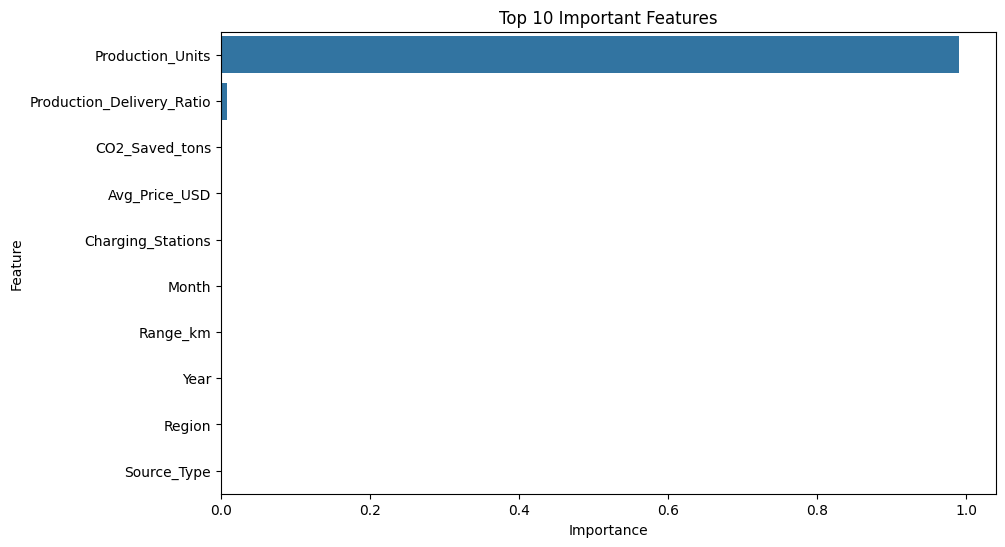

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_58/2331714738.py:259: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(



Next 12 Months Forecast
2026-01-01    203819.655291
2026-02-01    202894.176208
2026-03-01    199011.662577
2026-04-01    198667.010489
2026-05-01    200971.493839
2026-06-01    201391.449843
2026-07-01    201412.663910
2026-08-01    201031.409119
2026-09-01    200601.086701
2026-10-01    200710.068214
2026-11-01    200864.721560
2026-12-01    200936.680134
Freq: MS, Name: predicted_mean, dtype: float64


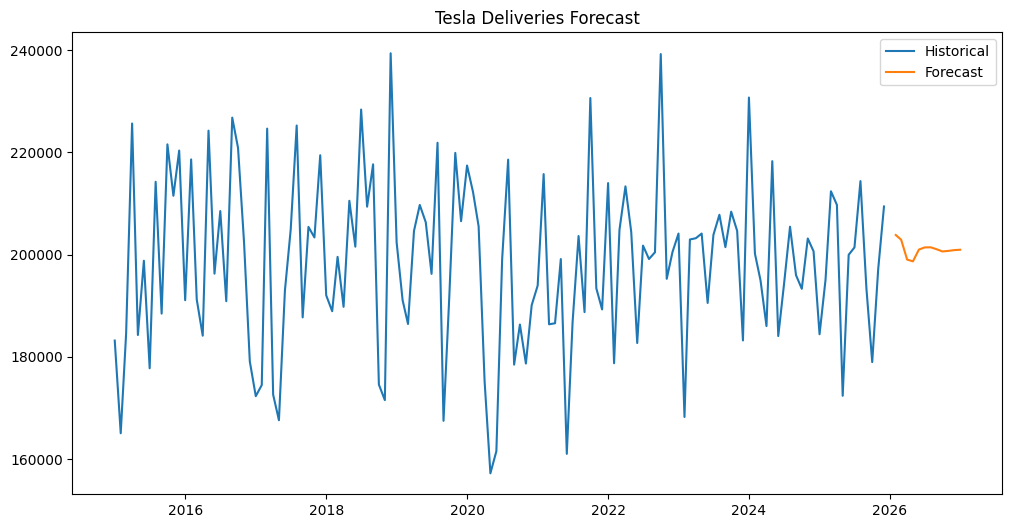

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
# =========================
# ==========================================
# TESLA DELIVERIES PREDICTION PROJECT
# ==========================================

# Install if needed
# !pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv(
    "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
)

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# DATASET INFO
# ==========================================

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# ==========================================
# FEATURE ENGINEERING
# ==========================================

df["Production_Delivery_Ratio"] = (
    df["Production_Units"] / df["Estimated_Deliveries"]
)

# ==========================================
# ENCODE CATEGORICAL COLUMNS
# ==========================================

label_encoders = {}

categorical_cols = ["Region", "Model", "Source_Type"]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# ==========================================
# EXPLORATORY DATA ANALYSIS
# ==========================================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)
plt.show()

# ==========================================
# DEFINE FEATURES & TARGET
# ==========================================

X = df.drop("Estimated_Deliveries", axis=1)

y = df["Estimated_Deliveries"]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# LINEAR REGRESSION
# ==========================================

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\nLINEAR REGRESSION")

print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score:",
      r2_score(y_test, lr_pred))

# ==========================================
# RANDOM FOREST
# ==========================================

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRANDOM FOREST")

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:",
      r2_score(y_test, rf_pred))

# ==========================================
# HYPERPARAMETER TUNING
# ==========================================

params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

best_pred = best_rf.predict(X_test)

print("\nTUNED RANDOM FOREST")

print("MAE:",
      mean_absolute_error(y_test, best_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, best_pred)))

print("R2 Score:",
      r2_score(y_test, best_pred))

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features")
print(importance.head(10))

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Important Features")
plt.show()

# ==========================================
# TIME SERIES FORECASTING
# ==========================================

ts_df = df.copy()

ts_df["Date"] = pd.to_datetime(
    ts_df["Year"].astype(str)
    + "-"
    + ts_df["Month"].astype(str)
)

monthly = ts_df.groupby("Date")[
    "Estimated_Deliveries"
].sum()

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly, order=(5,1,0))

model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

print("\nNext 12 Months Forecast")
print(forecast)

# ==========================================
# FORECAST VISUALIZATION
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(
    monthly.index,
    monthly.values,
    label="Historical"
)

future_dates = pd.date_range(
    monthly.index.max(),
    periods=13,
    freq="M"
)[1:]

plt.plot(
    future_dates,
    forecast,
    label="Forecast"
)

plt.legend()

plt.title(
    "Tesla Deliveries Forecast"
)

plt.show()